# Laboratorio 1: Prediccion y Clasificacion en la Industria Azucarera

**Fase:** Correccion de clasificacion  
**Autores:** TODO: completar autores  
**Fecha:** TODO: completar fecha


## 1. Objetivo

Este notebook corrige la parte de clasificacion para cumplir el enunciado original del laboratorio. A diferencia del modelamiento de regresion, la clasificacion debe usar el dataset `BD_IPSA_1940.xlsx`.

Se construyen clases de desempeno para `TCH` y para la variable de sacarosa disponible en IPSA, se entrenan modelos basicos y un modelo avanzado, y se reportan metricas claras de evaluacion.

La parte de regresion existente no se modifica.


## 2. Carga de datos

El archivo esperado es `data/raw/BD_IPSA_1940.xlsx`. Si el archivo no existe, el notebook muestra un mensaje claro y evita ejecutar las celdas dependientes de datos.


In [1]:
from datetime import datetime
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = BASE_DIR / "data" / "raw"
OUTPUT_TABLES_DIR = BASE_DIR / "outputs" / "tables"
OUTPUT_FIGURES_DIR = BASE_DIR / "outputs" / "figures"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
DATA_PATH = RAW_DIR / "BD_IPSA_1940.xlsx"

if DATA_PATH.exists():
    ipsa = pd.read_excel(DATA_PATH)
    data_available = True
    print(f"Dataset cargado: {DATA_PATH}")
else:
    ipsa = pd.DataFrame()
    data_available = False
    print(f"No se encontro el archivo requerido: {DATA_PATH}")
    print("Ubica BD_IPSA_1940.xlsx en data/raw/ y vuelve a ejecutar el notebook.")


Dataset cargado: /Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/data/raw/BD_IPSA_1940.xlsx


## 3. Exploracion minima

Se revisan dimensiones, columnas y primeras filas. Esta seccion no reemplaza el EDA completo de la Tarea 2.


In [2]:
if data_available:
    print("Shape:", ipsa.shape)
    print("Columnas:")
    print(list(ipsa.columns))
    display(ipsa.head())
else:
    print("Exploracion omitida porque no hay datos disponibles.")


Shape: (2187, 21)
Columnas:
['Unnamed: 0', 'NOME', 'FAZ', 'TAL', 'tipocorte', 'variedad', 'madurada', 'producto', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'sacarosa', 'mes', 'periodo', 'TCH', 'lluvias', 'grupo_tenencia', 'pct_diatrea']


,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


## 4. Creacion de variables objetivo

El enunciado solicita clasificar desempeno a partir de `TCH` y `%Sac.Caña`. Al inspeccionar el dataset real `BD_IPSA_1940.xlsx`, la columna `%Sac.Caña` no existe; la variable equivalente disponible para calidad es `sacarosa`. Por tanto, se crea:

- `TCH_class` desde `TCH`
- `SAC_class` desde `sacarosa`

Ambas se discretizan en terciles: `bajo`, `medio` y `alto`.


In [3]:
TARGET_TCH = "TCH"
TARGET_SAC_REQUESTED = "%Sac.Caña"
TARGET_SAC_REAL = "sacarosa"
CLASS_LABELS = ["bajo", "medio", "alto"]

required_targets = [TARGET_TCH, TARGET_SAC_REAL]

if data_available:
    missing_targets = [column for column in required_targets if column not in ipsa.columns]
    if missing_targets:
        modeling_available = False
        print("No se pueden crear las clases. Faltan columnas:", missing_targets)
    else:
        modeling_available = True
        df = ipsa.copy()
        if TARGET_SAC_REQUESTED not in df.columns:
            print(f"Nota: '{TARGET_SAC_REQUESTED}' no existe en BD_IPSA_1940.xlsx; se usa '{TARGET_SAC_REAL}'.")
        df["TCH_class"] = pd.qcut(df[TARGET_TCH], 3, labels=CLASS_LABELS)
        df["SAC_class"] = pd.qcut(df[TARGET_SAC_REAL], 3, labels=CLASS_LABELS)
        display(df[[TARGET_TCH, "TCH_class", TARGET_SAC_REAL, "SAC_class"]].head())
        display(
            pd.DataFrame(
                {
                    "TCH_class": df["TCH_class"].value_counts().reindex(CLASS_LABELS),
                    "SAC_class": df["SAC_class"].value_counts().reindex(CLASS_LABELS),
                }
            )
        )
else:
    modeling_available = False
    print("Creacion de variables objetivo omitida porque no hay datos disponibles.")


Nota: '%Sac.Caña' no existe en BD_IPSA_1940.xlsx; se usa 'sacarosa'.


,TCH,TCH_class,sacarosa,SAC_class
0,112,bajo,14.0,alto
1,157,alto,13.0,medio
2,167,alto,13.3,alto
3,156,alto,13.4,alto
4,151,medio,14.0,alto


,TCH_class,SAC_class
bajo,754,761
medio,705,710
alto,728,716


## 5. Variables predictoras y preprocesamiento

Se usan columnas reales del dataset IPSA. Se excluyen identificadores administrativos (`NOME`, `FAZ`, `TAL`, `periodo`, `Unnamed: 0`) y las variables objetivo continuas (`TCH`, `sacarosa`) para evitar fuga de informacion.

El preprocesamiento queda encapsulado en `Pipeline`: imputacion, one-hot encoding para categoricas y escalado solo para modelos sensibles a escala.


In [4]:
NUMERIC_FEATURES = ["dosismad", "semsmad", "edad", "cortes", "me", "vejez", "lluvias", "pct_diatrea"]
CATEGORICAL_FEATURES = ["tipocorte", "variedad", "madurada", "producto", "grupo_tenencia", "mes"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

if modeling_available:
    missing_features = [column for column in FEATURES if column not in df.columns]
    if missing_features:
        modeling_available = False
        print("No se puede modelar. Faltan variables predictoras:", missing_features)
    else:
        print("Variables numericas:", NUMERIC_FEATURES)
        print("Variables categoricas:", CATEGORICAL_FEATURES)
        display(df[FEATURES].isna().sum().to_frame("nulos"))
else:
    print("Seleccion de variables omitida porque no hay datos listos para modelar.")

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

def make_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ]
    )

def make_pipeline(model, scale_numeric=False):
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", model),
        ]
    )


Variables numericas: ['dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'lluvias', 'pct_diatrea']
Variables categoricas: ['tipocorte', 'variedad', 'madurada', 'producto', 'grupo_tenencia', 'mes']


,nulos
dosismad,0
semsmad,0
edad,0
cortes,0
me,0
vejez,0
lluvias,0
pct_diatrea,0
tipocorte,0
variedad,0


## 6. Modelos y metricas

Se comparan modelos basicos y uno avanzado sin tuning complejo:

- `DummyClassifier`: linea base trivial.
- `LogisticRegression`: modelo lineal interpretable.
- `KNeighborsClassifier`: modelo no parametrico basico.
- `RandomForestClassifier`: modelo avanzado de arboles.

Metricas: accuracy, precision macro, recall macro, F1 macro y Kappa de Cohen.


In [5]:
SCORING = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "kappa": make_scorer(cohen_kappa_score),
}

CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

MODEL_CONFIGS = {
    "DummyClassifier": {
        "pipeline": make_pipeline(DummyClassifier(strategy="most_frequent"), scale_numeric=False),
    },
    "LogisticRegression": {
        "pipeline": make_pipeline(
            LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42),
            scale_numeric=True,
        ),
    },
    "KNeighborsClassifier": {
        "pipeline": make_pipeline(
            KNeighborsClassifier(n_neighbors=11, weights="distance", p=2),
            scale_numeric=True,
        ),
    },
    "RandomForestClassifier": {
        "pipeline": make_pipeline(
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
            scale_numeric=False,
        ),
    },
}

def summarize_cv_scores(cv_scores):
    summary = {}
    for metric_name, values in cv_scores.items():
        if metric_name.startswith("test_"):
            summary[f"cv_{metric_name.replace('test_', '')}"] = float(np.mean(values))
    return summary

def evaluate_classifier(target_name, y_column):
    X = df[FEATURES]
    y = df[y_column].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )

    target_results = []
    target_artifacts = {}

    for model_name, config in MODEL_CONFIGS.items():
        pipeline = config["pipeline"]
        fitted_model = pipeline.fit(X_train, y_train)
        cv_scores = cross_validate(
            fitted_model,
            X_train,
            y_train,
            cv=CV,
            scoring=SCORING,
            n_jobs=1,
        )
        y_pred = fitted_model.predict(X_test)

        result = {
            "target": target_name,
            "modelo": model_name,
            **summarize_cv_scores(cv_scores),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "test_recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "test_kappa": cohen_kappa_score(y_test, y_pred),
        }
        target_results.append(result)
        target_artifacts[model_name] = {
            "model": fitted_model,
            "y_test": y_test,
            "y_pred": y_pred,
            "report": classification_report(y_test, y_pred, zero_division=0),
        }

    return target_results, target_artifacts


## 7. Entrenamiento y resultados

Se entrenan modelos separados para `TCH_class` y `SAC_class`. Las tablas se guardan con `RUN_ID` para no sobrescribir resultados existentes.


In [6]:
classification_results = []
classification_artifacts = {}

if modeling_available:
    for target_name, y_column in {"TCH_class": "TCH_class", "SAC_class": "SAC_class"}.items():
        results, artifacts = evaluate_classifier(target_name, y_column)
        classification_results.extend(results)
        classification_artifacts[target_name] = artifacts

    resumen_clasificacion_corregida = pd.DataFrame(classification_results).sort_values(
        ["target", "test_f1_macro"], ascending=[True, False]
    )
    mejores_clasificacion_corregida = (
        resumen_clasificacion_corregida.sort_values(
            ["target", "test_f1_macro", "test_accuracy"], ascending=[True, False, False]
        )
        .groupby("target", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    print("Resumen de clasificacion corregida")
    display(resumen_clasificacion_corregida.round(4))
    print("Mejores modelos por objetivo")
    display(mejores_clasificacion_corregida.round(4))

    summary_path = OUTPUT_TABLES_DIR / f"clasificacion_corregida_resumen_{RUN_ID}.csv"
    best_path = OUTPUT_TABLES_DIR / f"clasificacion_corregida_mejores_{RUN_ID}.csv"
    resumen_clasificacion_corregida.to_csv(summary_path, index=False)
    mejores_clasificacion_corregida.to_csv(best_path, index=False)

    print("Tablas nuevas guardadas:")
    print(summary_path)
    print(best_path)
else:
    print("Entrenamiento omitido porque no hay datos o columnas suficientes.")


/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE

/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE

Resumen de clasificacion corregida


,target,modelo,cv_accuracy,cv_precision_macro,cv_recall_macro,cv_f1_macro,cv_kappa,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_kappa
7,SAC_class,RandomForestClassifier,0.5249,0.5150,0.5224,0.5174,0.2864,0.5776,0.5687,0.5761,0.5647,0.3662
5,SAC_class,LogisticRegression,0.5111,0.4934,0.5084,0.4953,0.2653,0.5662,0.5539,0.5642,0.5485,0.3484
6,SAC_class,KNeighborsClassifier,0.4831,0.4812,0.4822,0.4800,0.2250,0.5091,0.5077,0.5091,0.5042,0.2647
4,SAC_class,DummyClassifier,0.3476,0.1159,0.3333,0.1720,0.0000,0.3493,0.1164,0.3333,0.1726,0.0000
3,TCH_class,RandomForestClassifier,0.4717,0.4703,0.4709,0.4697,0.2076,0.5160,0.5214,0.5154,0.5169,0.2748
2,TCH_class,KNeighborsClassifier,0.4374,0.4358,0.4365,0.4349,0.1557,0.4749,0.4754,0.4741,0.4744,0.2126
1,TCH_class,LogisticRegression,0.4477,0.4462,0.4461,0.4405,0.1699,0.4384,0.4273,0.4362,0.4294,0.1564
0,TCH_class,DummyClassifier,0.3448,0.1149,0.3333,0.1709,0.0000,0.3447,0.1149,0.3333,0.1709,0.0000


Mejores modelos por objetivo


,target,modelo,cv_accuracy,cv_precision_macro,cv_recall_macro,cv_f1_macro,cv_kappa,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_kappa
0,SAC_class,RandomForestClassifier,0.5249,0.5150,0.5224,0.5174,0.2864,0.5776,0.5687,0.5761,0.5647,0.3662
1,TCH_class,RandomForestClassifier,0.4717,0.4703,0.4709,0.4697,0.2076,0.5160,0.5214,0.5154,0.5169,0.2748


Tablas nuevas guardadas:
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/tables/clasificacion_corregida_resumen_20260430_204443.csv
/Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/tables/clasificacion_corregida_mejores_20260430_204443.csv


## 8. Visualizaciones de apoyo

Se guardan matrices de confusion para los mejores modelos y graficos de importancia de variables para Random Forest. Los nombres incluyen `RUN_ID` para no sobrescribir figuras existentes.


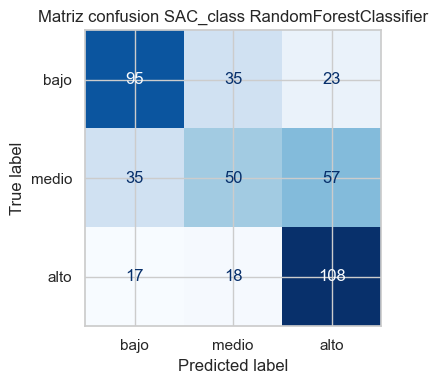

Figura guardada: /Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/figures/clasificacion_corregida_matriz_confusion_sac_class_randomforestclassifier_20260430_204443.png


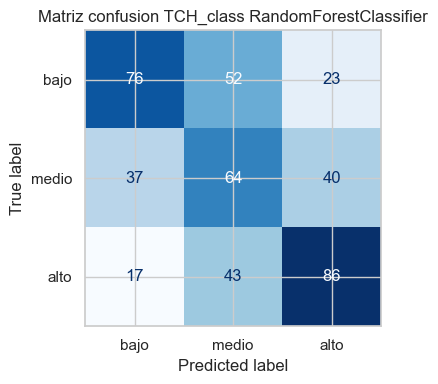

Figura guardada: /Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/figures/clasificacion_corregida_matriz_confusion_tch_class_randomforestclassifier_20260430_204443.png


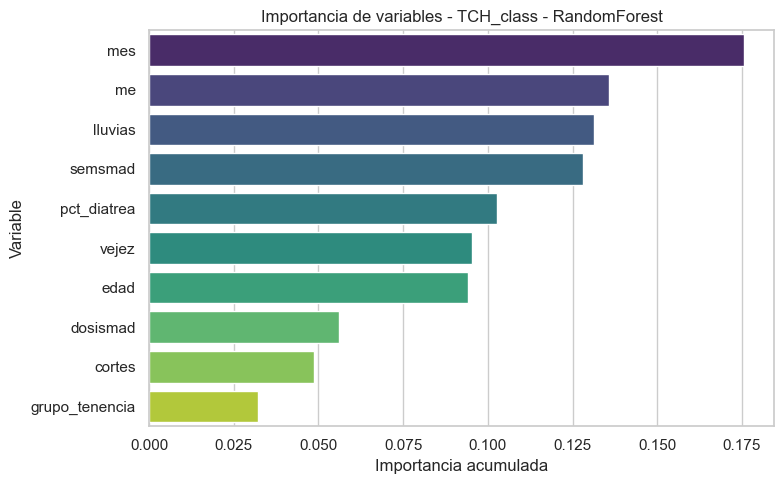

Figura guardada: /Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/figures/clasificacion_corregida_importancia_tch_class_20260430_204443.png


,variable,importance
6,mes,0.1757
5,me,0.1359
4,lluvias,0.1313
8,semsmad,0.1280
7,pct_diatrea,0.1028
9,vejez,0.0955
2,edad,0.0942
1,dosismad,0.0560
0,cortes,0.0486
3,grupo_tenencia,0.0321


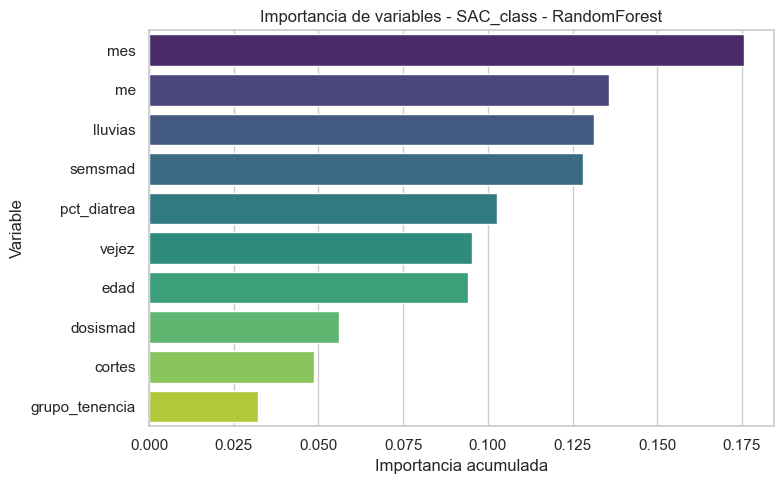

Figura guardada: /Users/esuetorres/Library/CloudStorage/OneDrive-UniversidadIcesi(@icesi.edu.co)/Icesi/SEMESTRE VII/APOIII/Lab-Industria-azucarera-APOIII/laboratorio_azucar/outputs/figures/clasificacion_corregida_importancia_sac_class_20260430_204443.png


,variable,importance
6,mes,0.1757
5,me,0.1359
4,lluvias,0.1313
8,semsmad,0.1280
7,pct_diatrea,0.1028
9,vejez,0.0955
2,edad,0.0942
1,dosismad,0.0560
0,cortes,0.0486
3,grupo_tenencia,0.0321


In [7]:
def make_safe_filename(text):
    replacements = {"%": "pct", "ñ": "n", "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u"}
    clean_text = text.lower()
    for old, new in replacements.items():
        clean_text = clean_text.replace(old, new)
    clean_text = "".join(char if char.isalnum() else "_" for char in clean_text)
    clean_text = "_".join(part for part in clean_text.split("_") if part)
    return clean_text

def save_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    output_path = OUTPUT_FIGURES_DIR / f"clasificacion_corregida_{make_safe_filename(title)}_{RUN_ID}.png"
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", output_path)

def get_feature_names(fitted_pipeline):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    return preprocessor.get_feature_names_out()

def collapse_feature_name(name):
    clean_name = name.split("__", 1)[1] if "__" in name else name
    for variable in CATEGORICAL_FEATURES:
        if clean_name.startswith(f"{variable}_"):
            return variable
    return clean_name

def save_rf_importance(target_name):
    model = classification_artifacts[target_name]["RandomForestClassifier"]["model"]
    feature_names = get_feature_names(model)
    importances = model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    grouped = (
        importance_df.assign(variable=importance_df["feature"].map(collapse_feature_name))
        .groupby("variable", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(data=grouped, x="importance", y="variable", palette="viridis")
    plt.title(f"Importancia de variables - {target_name} - RandomForest")
    plt.xlabel("Importancia acumulada")
    plt.ylabel("Variable")
    plt.tight_layout()
    output_path = OUTPUT_FIGURES_DIR / f"clasificacion_corregida_importancia_{target_name.lower()}_{RUN_ID}.png"
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", output_path)
    display(grouped.round(4))

if modeling_available:
    for _, row in mejores_clasificacion_corregida.iterrows():
        artifact = classification_artifacts[row["target"]][row["modelo"]]
        save_confusion_matrix(
            artifact["y_test"],
            artifact["y_pred"],
            f"Matriz confusion {row['target']} {row['modelo']}",
        )

    for target_name in ["TCH_class", "SAC_class"]:
        save_rf_importance(target_name)
else:
    print("Visualizaciones omitidas porque no se entrenaron modelos.")


## 9. Lectura para el informe

- Esta correccion usa `BD_IPSA_1940.xlsx`, como exige el enunciado para clasificacion.
- `SAC_class` se crea desde `sacarosa` porque `%Sac.Caña` no existe en IPSA.
- Los resultados deben interpretarse como clasificacion de desempeno en terciles, no como prediccion exacta de valores continuos.
- Las salidas generadas por este notebook tienen nombres nuevos y no sobrescriben los resultados previos del cuaderno de modelamiento.
